#  Clasificación Multiclase con PyTorch
## Tabular Playground Series — May 2021 (Kaggle)

> **Disertación:** Este cuadernillo explica **paso a paso** cómo entrenar una red neuronal  
> profunda con PyTorch para clasificar 4 categorías de productos de e-commerce.




---
##  Paso 2 — Cargar el dataset

Cargamos `train.csv` directamente desde Google Drive.  
Verificamos:
- ¿Cuántas filas/columnas hay?
- ¿Hay valores nulos?
- ¿Cómo se distribuyen las 4 clases?


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
SEED = 42

In [ ]:

#from google.colab import drive; drive.mount('/content/drive')
RUTA = './Lab4/train.csv'
df = pd.read_csv(RUTA)
print(f'Dimensiones : {df.shape}')
print(f'Nulos totales: {df.isnull().sum().sum()}')
print()
print('Distribución de clases:')
print(df['target'].value_counts())
df.head(3)

Dimensiones : (100000, 52)
Nulos totales: 0

Distribución de clases:
target
Class_2    57497
Class_3    21420
Class_4    12593
Class_1     8490
Name: count, dtype: int64


,id,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,target
0,0,0,0,1,0,1,0,0,0,0,...,0,0,21,0,0,0,0,0,0,Class_2
1,1,0,0,0,0,2,1,0,0,0,...,0,0,0,0,0,0,0,0,0,Class_1
2,2,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,13,2,0,Class_1


---
##  Paso 3 — Exploración visual (EDA)

Antes de entrenar, siempre exploramos los datos:
1. Distribución de las 4 clases
2. Distribución de las primeras features (para ver si hay outliers)

> **¿Por qué?**  
> Si las clases están desbalanceadas, el modelo aprende a predecir siempre la clase mayoritaria.  
> Si las features tienen escalas muy distintas, el gradiente diverge.


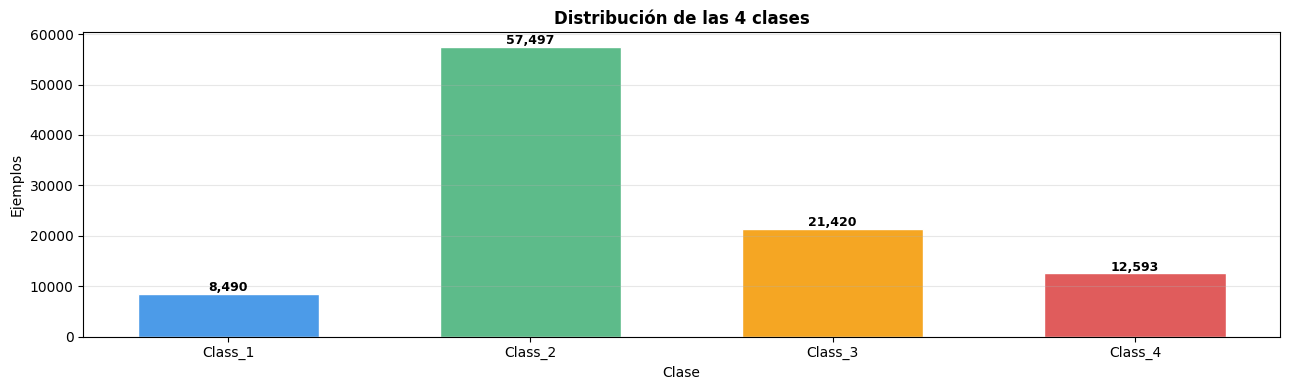

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))

# — Distribución de clases —
conteo = df['target'].value_counts().sort_index()
colores = ['#4C9BE8', '#5DBB8A', '#F5A623', '#E05C5C']
bars = ax.bar(conteo.index, conteo.values, color=colores, edgecolor='white', width=0.6)
for bar, v in zip(bars, conteo.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 500,
            f'{v:,}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Distribución de las 4 clases', fontsize=12, fontweight='bold')
ax.set_xlabel('Clase'); ax.set_ylabel('Ejemplos')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
##  Paso 4 — Preprocesamiento

### 4.1 Balanceo de clases (Undersampling)

usamos undersampling: reducimos todas las clases  
al tamaño de la **clase minoritaria** para que el modelo no favorezca ninguna.

$$n_{\text{min}} = \min(|C_0|, |C_1|, |C_2|, |C_3|)$$

### 4.2 Normalización Z-score

Cada feature se normaliza con:
$$x_{\text{norm}} = \frac{x - \mu}{\sigma}$$

> **Importante:** calculamos μ y σ **solo en train**, y los aplicamos en test.  
> Esto evita el **data leakage** (que el modelo "vea" información del test durante el entrenamiento).


In [ ]:
import numpy as np
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


In [ ]:
# ── 4.1 Undersampling ─────────────────────────────────────────
min_n  = df['target'].value_counts().min()
df_bal = pd.concat([
    resample(df[df['target'] == c], n_samples=min_n,
             replace=False, random_state=SEED)
    for c in df['target'].unique()
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Clase mínima      : {min_n:,}')
print(f'Total balanceado  : {len(df_bal):,}')
print(df_bal['target'].value_counts())

Clase mínima      : 8,490
Total balanceado  : 33,960
target
Class_3    8490
Class_4    8490
Class_2    8490
Class_1    8490
Name: count, dtype: int64


In [ ]:
# ── 4.2 Features, etiquetas y split ──────────────────────────
COLS = [f'feature_{i}' for i in range(50)]
le   = LabelEncoder()

X    = df_bal[COLS].values.astype(np.float32)
y    = le.fit_transform(df_bal['target'])        # clases → enteros 0/1/2/3

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

# ── Normalización Z-score ─────────────────────────────────────
X_train = featureNormalize(X_train)          # fit SOLO en train
X_test  = featureNormalize(X_test)               # transform en test

print(f'Train : {X_train.shape} | Test: {X_test.shape}')
print(f'Clases: {le.classes_}')
print(f'Post-normalización → media≈{X_train.mean():.3f}  std≈{X_train.std():.3f}')

Train : (27168, 50) | Test: (6792, 50)
Clases: ['Class_1' 'Class_2' 'Class_3' 'Class_4']
Post-normalización → media≈-0.000  std≈1.000


### 4.4 Balance de clases — antes vs después del undersampling


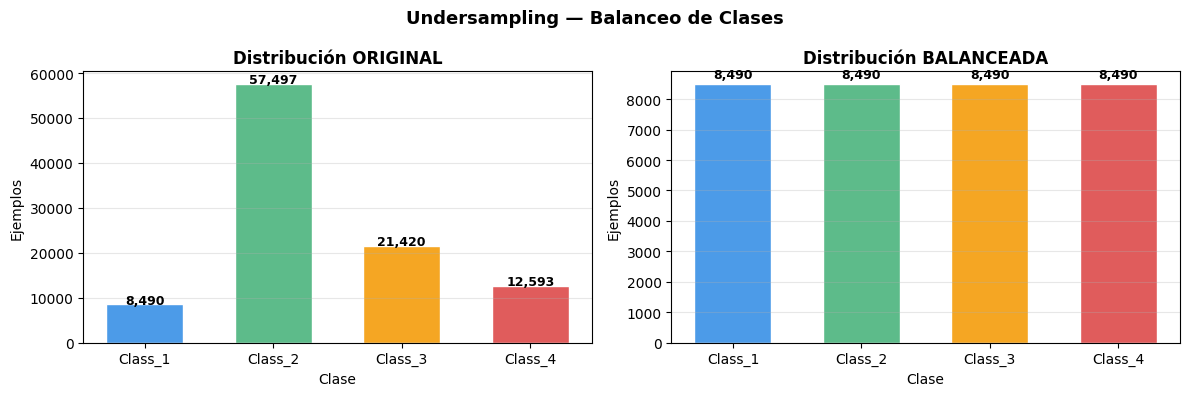

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colores = ['#4C9BE8','#5DBB8A','#F5A623','#E05C5C']

orig = df['target'].value_counts().sort_index()
bal  = df_bal['target'].value_counts().sort_index()

for ax, datos, titulo in zip(axes, [orig, bal],
                              ['Distribución ORIGINAL', 'Distribución BALANCEADA']):
    bars = ax.bar(datos.index, datos.values, color=colores, edgecolor='white', width=0.6)
    for bar, v in zip(bars, datos.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 200,
                f'{v:,}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Clase'); ax.set_ylabel('Ejemplos')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Undersampling — Balanceo de Clases', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# función de pérdida y derivada

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

def cross_entropy(output, target):
    logits = output[torch.arange(len(output)), target]
    loss = - logits + torch.log(torch.sum(torch.exp(output), axis=-1))
    loss = loss.mean()
    return loss

---
##  Paso 5 — `Dataset` y `DataLoader` 

### ¿Por qué usar `Dataset` y `DataLoader`?


Es mejor usar la clase `Dataset` de PyTorch, que:
- Maneja el **shuffle** automáticamente cada época
- Permite **mini-batches** de forma eficiente
- Es **reutilizable** para train, val y predicción

```
Dataset ──► DataLoader ──► mini-batches automáticos ──► modelo
```


In [ ]:
class TPSDataset(Dataset):
    """
    Dataset tabular para TPS May-2021.
    Hereda de torch.utils.data.Dataset (cuadernillo 03).
    Implementa los tres métodos obligatorios:
      __init__  → guarda X e y como tensores
      __len__   → devuelve el número de muestras
      __getitem__→ devuelve un par (X[i], y[i])
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)     # long para CrossEntropyLoss

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

# Instanciar datasets
ds_train = TPSDataset(X_train, y_train)
ds_test  = TPSDataset(X_test,  y_test)
print(f'Dataset train: {len(ds_train):,} muestras')
print(f'Dataset test : {len(ds_test):,} muestras')
print(f'Ejemplo [0]  : X={ds_train[0][0].shape}  y={ds_train[0][1]}')

Dataset train: 27,168 muestras
Dataset test : 6,792 muestras
Ejemplo [0]  : X=torch.Size([50])  y=2


In [ ]:
# DataLoader: empaqueta el Dataset en mini-batches
# shuffle=True en train para evitar que el modelo aprenda el orden
dl_train = DataLoader(ds_train, batch_size=512, shuffle=True,  num_workers=0, pin_memory=True)
dl_test  = DataLoader(ds_test,  batch_size=512, shuffle=False, num_workers=0)

print(f'Batches por época (train): {len(dl_train)}')
print(f'Batches por época (test) : {len(dl_test)}')

# Verificar un batch
xb, yb = next(iter(dl_train))
print(f'\nEjemplo de batch → X: {xb.shape}  y: {yb.shape}')

Batches por época (train): 54
Batches por época (test) : 14

Ejemplo de batch → X: torch.Size([512, 50])  y: torch.Size([512])


---
##  Paso 6 — Arquitectura con `nn.Module` 

### ¿Por qué `nn.Module` en vez de `Sequential`?

 define el modelo como clase que hereda de `nn.Module`.  
Esto da **control total** del `forward` y permite:
- Capas con nombres descriptivos (`self.fc1`, `self.fc2batchnorm`...)
- Arquitecturas no lineales (residuales, ramas múltiples)
- Fácil acceso a parámetros individuales

### Arquitectura expandida 

El modelo  **expande** la dimensión hasta un máximo y luego **la reduce**:

```
Input(50) → starter(s) → s×2 → s×4 → s×2 → Output(4)
               ↑ BN+Act  ↑BN+Act ↑BN+Act ↑BN+Act
```

Donde `starter` es un hiperparámetro a buscar (16, 32, 64, 128, 256, 512).


In [ ]:
class ModelTPS(nn.Module):
    """
    Red neuronal tabular inspirada en el cuadernillo 00.
    Expande la dimensión hasta starter×4 y luego la reduce.

    Parámetros
    ----------
    input_dim  : número de features de entrada (50 para TPS)
    starter    : tamaño inicial de la capa oculta (hiperparámetro)
    n_classes  : número de clases de salida (4 para TPS)
    activation : función de activación (ReLU, LeakyReLU, ELU, SiLU...)
    dropout    : tasa de dropout para regularización
    """
    def __init__(self, input_dim=50, starter=64,
                 n_classes=4, activation=None, dropout=0.25):
        super().__init__()
        if activation is None:
            activation = nn.ReLU()
        self.activation = activation

        # — Bloque 1: input → starter —
        self.fc1      = nn.Linear(input_dim, starter)
        self.bn1      = nn.BatchNorm1d(starter)
        self.drop1    = nn.Dropout(dropout)

        # — Bloque 2: starter → starter×2 —
        self.fc2      = nn.Linear(starter, starter * 2)
        self.bn2      = nn.BatchNorm1d(starter * 2)
        self.drop2    = nn.Dropout(dropout)

        # — Bloque 3: starter×2 → starter×4 (expansión máxima) —
        self.fc3      = nn.Linear(starter * 2, starter * 4)
        self.bn3      = nn.BatchNorm1d(starter * 4)
        self.drop3    = nn.Dropout(dropout)

        # — Bloque 4: starter×4 → starter×2 (contracción) —
        self.fc4      = nn.Linear(starter * 4, starter * 2)
        self.bn4      = nn.BatchNorm1d(starter * 2)
        self.drop4    = nn.Dropout(dropout)

        # — Cabeza de salida —
        self.output   = nn.Linear(starter * 2, n_classes)

    def forward(self, x):
        # Bloque 1
        x = self.drop1(self.activation(self.bn1(self.fc1(x))))
        # Bloque 2
        x = self.drop2(self.activation(self.bn2(self.fc2(x))))
        # Bloque 3
        x = self.drop3(self.activation(self.bn3(self.fc3(x))))
        # Bloque 4
        x = self.drop4(self.activation(self.bn4(self.fc4(x))))
        # Salida (logits crudos → CrossEntropyLoss aplica Softmax)
        return self.output(x)

# Prueba rápida con starter=64
model_test = ModelTPS(input_dim=50, starter=64)
dummy = torch.randn(8, 50)
out   = model_test(dummy)
print(f'Output shape: {out.shape}  (esperado: [8, 4])')
total_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'Parámetros entrenables (starter=64): {total_params:,}')

Output shape: torch.Size([8, 4])  (esperado: [8, 4])
Parámetros entrenables (starter=64): 79,172


### 6.3 Comparativa de arquitecturas con distintos `starter`

Mostramos cómo cambia la red al variar `starter`.


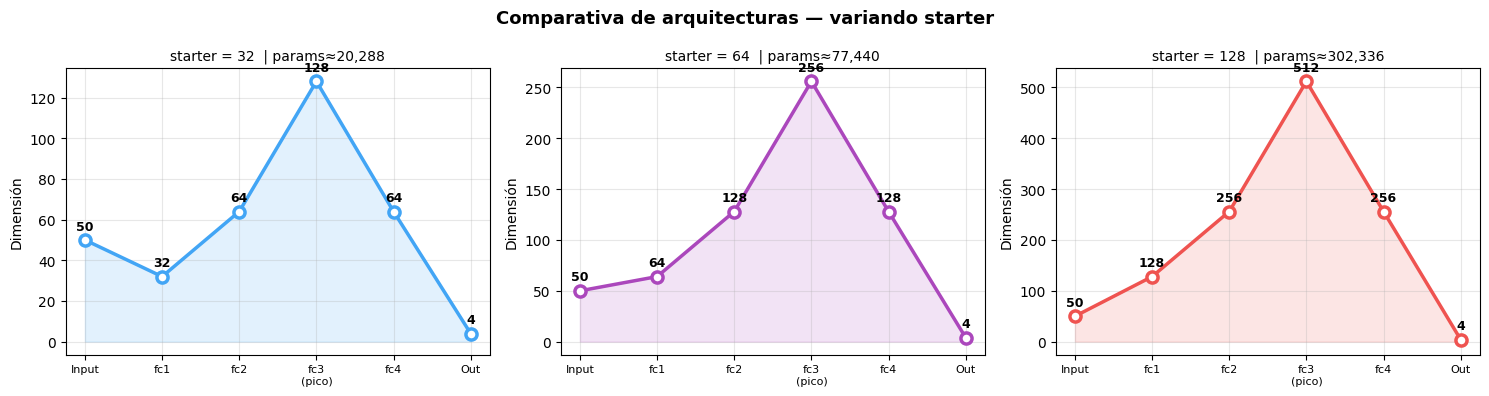

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
starters = [32, 64, 128]
colores_s = ['#42A5F5','#AB47BC','#EF5350']

for ax, s, col in zip(axes, starters, colores_s):
    dims = [50, s, s*2, s*4, s*2, 4]
    x    = list(range(len(dims)))
    ax.plot(x, dims, 'o-', color=col, lw=2.5, markersize=8, markerfacecolor='white',
            markeredgewidth=2.5)
    ax.fill_between(x, dims, alpha=0.15, color=col)
    for xi, d in zip(x, dims):
        ax.text(xi, d + max(dims)*0.04, str(d), ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'starter = {s}  | params≈{50*s + s*s*2 + s*2*s*4 + s*4*s*2 + s*2*4:,}',
                 fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(['Input','fc1','fc2','fc3\n(pico)','fc4','Out'], fontsize=8)
    ax.set_ylabel('Dimensión'); ax.grid(alpha=0.3)

plt.suptitle('Comparativa de arquitecturas — variando starter', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
##  Paso 7 — Función `evaluate` o test

 separa el cálculo del accuracy en una función independiente `test()`.  
La adaptamos para multiclase (4 clases) usando `DataLoader` para mayor eficiencia.




In [ ]:
def evaluate(model, dl, device='cpu'):
    """
    Calcula accuracy y log-loss sobre un DataLoader.
    """
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            logits = model(xb)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            preds  = logits.argmax(dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    model.train()   # volver a modo entrenamiento (como en cuadernillo 00)

    acc  = accuracy_score(all_labels, all_preds)
    loss = log_loss(all_labels, all_probs)
    return acc, loss, np.array(all_preds), np.array(all_labels)

print('✔  Función evaluate() definida')

✔  Función evaluate() definida


---
##  Entrenamiento final con la mejor configuración

Ahora que `ray.tune` encontró la mejor configuración, entrenamos el modelo final  
con **más épocas** y todas las técnicas del cuadernillo **02/03/04**:

- `tqdm` para barra de progreso (cuadernillo 00)
- `ReduceLROnPlateau` — scheduler adaptativo (cuadernillo 04)
- **Early stopping** — para cuando deja de mejorar
- **Checkpoint** automático del mejor modelo (cuadernillo 04)


In [ ]:
# ── Construir modelo final con una configuración fija ─────────
import random
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

SEED_TPS = 7
random.seed(SEED_TPS)
np.random.seed(SEED_TPS)
torch.manual_seed(SEED_TPS)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_TPS)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

best_config = {
    "starter": 64,
    "activation": nn.SiLU(),
    "optimizer": optim.AdamW,
    "lr": 1e-3,
    "dropout": 0.25,
    "criterion": nn.CrossEntropyLoss,
    "weight_decay": 1e-4,
}

model = ModelTPS(
    input_dim=50,
    starter=best_config["starter"],
    n_classes=4,
    activation=best_config["activation"],
    dropout=best_config["dropout"],
).to(device)

criterion = best_config["criterion"]()
optimizer = best_config["optimizer"](
    model.parameters(),
    lr=best_config["lr"],
    weight_decay=best_config["weight_decay"],
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
)

EPOCHS = 100
PATIENCE = 15
CHECKPOINT = "tps_best.pt"

total_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Modelo final — starter={best_config['starter']}")
print(f"Parámetros entrenables: {total_p:,}")
print(f"Épocas máximas: {EPOCHS}  |  Early stopping: {PATIENCE}")
print(f"Device: {device}")

Modelo final — starter=64
Parámetros entrenables: 79,172
Épocas máximas: 100  |  Early stopping: 15


In [ ]:
#fit
def fit(model, dl_train, dl_test, criterion, optimizer, scheduler,
        epochs=100, patience=15, checkpoint='best.pt', device='cpu'):
    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for xb, yb in dl_train:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)

        avg_loss = total_loss / len(dl_train.dataset)
        val_acc, val_loss, _, _ = evaluate(model, dl_test, device)

        print(f'Epoch {epoch:03d} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

        scheduler.step(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), checkpoint)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch}')
                break

In [ ]:
fit(
    model=model,
    dl_train=dl_train,
    dl_test=dl_test,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=EPOCHS,
    patience=PATIENCE,
    checkpoint=CHECKPOINT,
    device=device,
)

ckpt = torch.load(CHECKPOINT, map_location=device)
model.load_state_dict(ckpt["state_dict"])

print(f'\n✔ Mejor modelo cargado — época {ckpt["epoch"]}')
print(f'  val_loss = {ckpt["val_loss"]:.4f}')
print(f'  val_acc  = {ckpt["val_acc"]:.4f} ({ckpt["val_acc"]*100:.2f}%)')

Entrenando:  25%|██▌       | 25/100 [00:44<02:12,  1.76s/it]


  Early stop en época 26

✔ Mejor modelo cargado — época 11
  val_loss = 1.3726
  val_acc  = 0.3036 (30.36%)


---
##  Paso 10 — Visualizar el entrenamiento

Graficamos por separado (una gráfica por celda) la evolución de:
1. La función de pérdida (train vs val)
2. El accuracy de validación
3. El learning rate (schedule)

> **¿Por qué separadas?** Para que en la disertación cada gráfica tenga  
> su propia explicación y no se mezclen los conceptos.


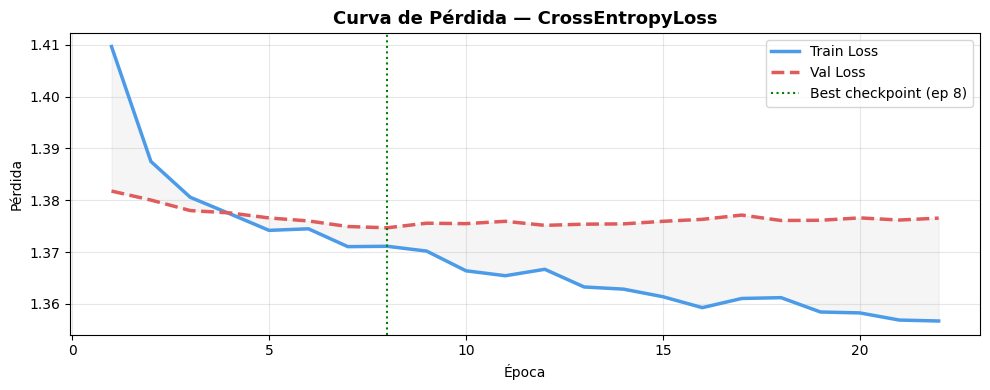

In [ ]:
# ── 10.1 Curva de pérdida ─────────────────────────────────────
ep    = [h['epoch']      for h in history]
tr_l  = [h['train_loss'] for h in history]
val_l = [h['val_loss']   for h in history]

plt.figure(figsize=(10, 4))
plt.plot(ep, tr_l,  lw=2.5, color='#4C9BE8', label='Train Loss')
plt.plot(ep, val_l, lw=2.5, color='#E05C5C', linestyle='--', label='Val Loss')
plt.fill_between(ep, tr_l, val_l, alpha=0.08, color='gray')

# Marcar el mejor checkpoint
best_ep = ckpt['epoch']
plt.axvline(best_ep, color='green', lw=1.5, linestyle=':', label=f'Best checkpoint (ep {best_ep})')

plt.title('Curva de Pérdida — CrossEntropyLoss', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Pérdida')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

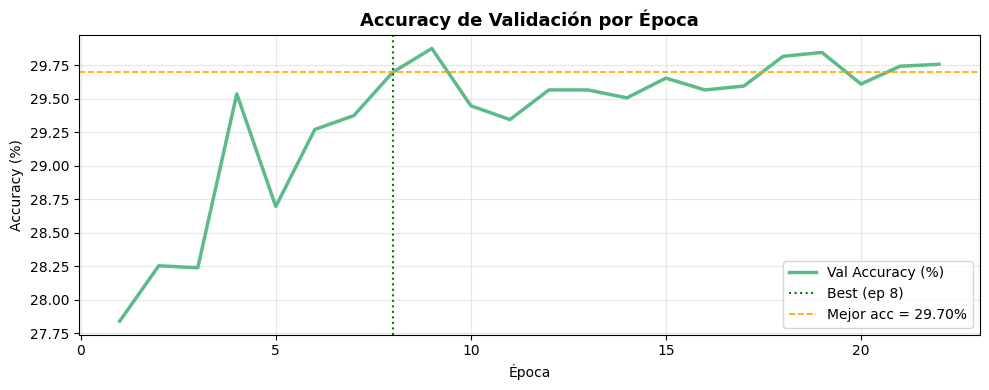

In [ ]:
# ── 10.2 Curva de Accuracy ───────────────────────────────────
val_a = [h['val_acc']*100 for h in history]

plt.figure(figsize=(10, 4))
plt.plot(ep, val_a, lw=2.5, color='#5DBB8A', label='Val Accuracy (%)')
plt.axvline(best_ep, color='green', lw=1.5, linestyle=':', label=f'Best (ep {best_ep})')
plt.axhline(ckpt['val_acc']*100, color='orange', lw=1.2, linestyle='--',
            label=f'Mejor acc = {ckpt["val_acc"]*100:.2f}%')

plt.title('Accuracy de Validación por Época', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Accuracy (%)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

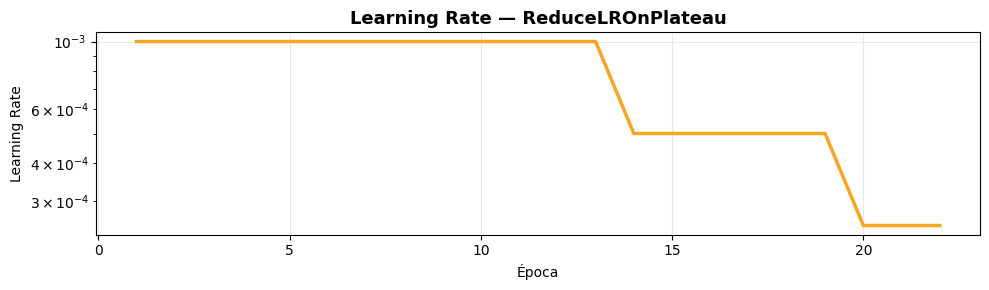

Cuando el LR baja → el scheduler detectó que val_loss dejó de mejorar.


In [ ]:
# ── 10.3 Learning Rate schedule ──────────────────────────────
lrs = [h['lr'] for h in history]

plt.figure(figsize=(10, 3))
plt.plot(ep, lrs, lw=2.5, color='#F5A623')
plt.title('Learning Rate — ReduceLROnPlateau', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Learning Rate')
plt.yscale('log'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('Cuando el LR baja → el scheduler detectó que val_loss dejó de mejorar.')

---
##  Paso 11 — Evaluación final del modelo

Cargamos el mejor checkpoint y evaluamos con métricas completas:
- **Accuracy** global
- **Classification report** (precision, recall, F1 por clase)
- **Log-loss**


In [ ]:
final_acc, final_loss, preds_final, labels_final = evaluate(model, dl_test, device)
print('=' * 55)
print('           EVALUACIÓN FINAL')
print('=' * 55)
print(f'  Accuracy  : {final_acc:.4f}  ({final_acc*100:.2f}%)')
print(f'  Log-Loss  : {final_loss:.4f}')
print()
print(classification_report(labels_final, preds_final, target_names=le.classes_))

---
##  Paso 12 — Métricas visuales

### 12.1 Matriz de confusión

Muestra cuántos ejemplos de cada clase **real** fueron predichos en cada clase.  
La diagonal = predicciones correctas.


In [ ]:
cm = confusion_matrix(labels_final, preds_final)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, linecolor='white')
plt.title('Matriz de Confusión — TPS May-2021', fontsize=13, fontweight='bold')
plt.ylabel('Clase Real', fontsize=11); plt.xlabel('Clase Predicha', fontsize=11)
plt.tight_layout(); plt.show()

### 12.2 Accuracy por clase

In [ ]:
acc_por_clase = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(8, 4))
bars = plt.bar(le.classes_, acc_por_clase * 100,
               color=['#4C9BE8','#5DBB8A','#F5A623','#E05C5C'],
               edgecolor='white', width=0.5)
for bar, v in zip(bars, acc_por_clase):
    plt.text(bar.get_x() + bar.get_width()/2, v*100 + 0.5,
             f'{v*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.ylim(0, 110)
plt.title('Accuracy por Clase', fontsize=13, fontweight='bold')
plt.xlabel('Clase'); plt.ylabel('Accuracy (%)')
plt.axhline(final_acc*100, color='gray', lw=1.5, linestyle='--', label=f'Promedio {final_acc*100:.1f}%')
plt.legend(); plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

### 12.3 Distribución de probabilidades Softmax por clase

In [ ]:
model.eval()
all_probs = []
with torch.no_grad():
    for xb, _ in dl_test:
        logits = model(xb.to(device))
        all_probs.extend(torch.softmax(logits, dim=1).cpu().numpy())
all_probs = np.array(all_probs)

fig, axes = plt.subplots(1, len(le.classes_), figsize=(14, 4), sharey=True)
pal = ['#4C9BE8','#5DBB8A','#F5A623','#E05C5C']
for i, (cls, col) in enumerate(zip(le.classes_, pal)):
    axes[i].hist(all_probs[:, i], bins=40, color=col, edgecolor='white', alpha=0.9)
    axes[i].set_title(f'P(clase={cls})', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Probabilidad Softmax'); axes[i].grid(alpha=0.3)
axes[0].set_ylabel('Frecuencia')
plt.suptitle('Distribución de Probabilidades Softmax por Clase', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
##  Paso 13 — Cómo cargar el checkpoint (cuadernillo 04)

El cuadernillo **04** nos enseña que el `state_dict` guarda **solo los pesos**,  
lo que es más eficiente que guardar el modelo completo.

```python
# Guardar (ya lo hicimos durante el entrenamiento)
torch.save({'state_dict': model.state_dict(), ...}, 'tps_best.pt')

# Cargar en cualquier momento (incluso en otra sesión)
ckpt  = torch.load('tps_best.pt')
model = ModelTPS(input_dim=50, starter=..., ...)   # misma arquitectura
model.load_state_dict(ckpt['state_dict'])
model.eval()
```


In [ ]:
# Verificar el contenido del checkpoint
ckpt_info = torch.load(CHECKPOINT, map_location='cpu')
print('Contenido del checkpoint guardado:')
for k, v in ckpt_info.items():
    if k == 'state_dict':
        n_tensors = len(v)
        total_w   = sum(p.numel() for p in v.values())
        print(f'  {k:<15}: {n_tensors} tensores | {total_w:,} pesos')
    else:
        print(f'  {k:<15}: {v}')

print()
print(f'Archivo guardado en: {CHECKPOINT}')

In [ ]:
# Demostración: cargar el checkpoint y hacer una predicción
model_loaded = ModelTPS(
    input_dim  = 50,
    starter    = best_config['starter'],
    n_classes  = 4,
    activation = best_config['activation'],
).to(device)

ckpt_loaded = torch.load(CHECKPOINT, map_location=device)
model_loaded.load_state_dict(ckpt_loaded['state_dict'])
model_loaded.eval()

# Predicción sobre las primeras 5 muestras del test
x_sample = torch.tensor(X_test[:5], dtype=torch.float32).to(device)
with torch.no_grad():
    logits  = model_loaded(x_sample)
    probs   = torch.softmax(logits, dim=1)
    pred_cl = logits.argmax(dim=1).cpu().numpy()

print('Predicciones sobre 5 muestras del test:')
print(f'  Clases disponibles : {le.classes_}')
print(f'  Predicciones (idx) : {pred_cl}')
print(f'  Predicciones (lbl) : {le.inverse_transform(pred_cl)}')
print(f'  Real               : {le.inverse_transform(y_test[:5])}')
print()
print('Probabilidades Softmax:')
for i, p in enumerate(probs.cpu().numpy()):
    print(f'  muestra {i}: {dict(zip(le.classes_, [f"{v:.3f}" for v in p]))}')

---
---
# 🏟 Tarea 1 — Clasificación Binaria: FIFA Player Stats
## ¿Es un jugador de FIFA élite? (Overall ≥ 80)

> **Disertación:** Aplicamos la misma arquitectura `nn.Module` del cuadernillo 00  
> pero para un problema **binario**: predecir si un jugador es élite o no.

---

### Dataset
- **Fuente:** [FIFA Player Stats — Kaggle](https://www.kaggle.com/datasets/bryanb/fifa-player-stats-database)
- **Tamaño:** ~35,487 jugadores · 40 features numéricas
- **Variable objetivo:** `élite = 1` si `Overall ≥ 80`, `0` si no

### Diferencias con Tarea 3
| Aspecto | Tarea 3 (TPS) | Tarea 1 (FIFA) |
|---|---|---|
| Clases | 4 | 2 (binario) |
| Pérdida | `CrossEntropyLoss` | `BCEWithLogitsLoss` (Sigmoide integrada) |
| Salida | 4 logits | 1 logit → `σ(z) > 0.5` |
| Features | 50 anónimas | 40 estadísticas de fútbol |


---
##  F1 — Cargar datos FIFA

Montamos Drive y cargamos el CSV combinado FIFA 17+18.


In [ ]:
# ── Montar Drive (Colab) ──────────────────────────────────────
# from google.colab import drive; drive.mount('/content/drive')
RUTA_FIFA = '/content/drive/MyDrive/Universida/IA/Dataset/Clasificacion/FIFA_17_18_combined.csv'
# RUTA_FIFA = './FIFA_17_18_combined.csv'   # ← local si prefieres

df_fifa = pd.read_csv(RUTA_FIFA)
print(f'Shape: {df_fifa.shape}')
print(f'Nulos: {df_fifa.isnull().sum().sum()}')
df_fifa.head(3)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Universida/IA/Dataset/Clasificacion/FIFA_17_18_combined.csv'

### F2 — Exploración: distribución Overall y balance de clases

In [ ]:
FEATURES_FIFA = [
    'Age','Potential','Crossing','Finishing','HeadingAccuracy','ShortPassing',
    'Volleys','Dribbling','Curve','FKAccuracy','LongPassing','BallControl',
    'Acceleration','SprintSpeed','Agility','Reactions','Balance','ShotPower',
    'Jumping','Stamina','Strength','LongShots','Aggression','Interceptions',
    'Positioning','Vision','Penalties','Composure','Marking','StandingTackle',
    'SlidingTackle','GKDiving','GKHandling','GKKicking','GKPositioning',
    'GKReflexes','International Reputation','Weak Foot','Skill Moves','FIFA_Year'
]

df_f  = df_fifa[FEATURES_FIFA + ['Overall']].dropna()
y_raw = (df_f['Overall'] >= 80).astype(int).values
n_elite    = y_raw.sum()
n_no_elite = (y_raw == 0).sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma Overall
axes[0].hist(df_f['Overall'], bins=40, color='#4C9BE8', edgecolor='white')
axes[0].axvline(80, color='red', lw=2, linestyle='--', label='Umbral élite (80)')
axes[0].set_title('Distribución de Overall', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Overall'); axes[0].set_ylabel('Jugadores'); axes[0].legend()
axes[0].grid(alpha=0.3)

# Balance élite / no élite
axes[1].bar(['No élite (0)','Élite (1)'], [n_no_elite, n_elite],
            color=['#E05C5C','#5DBB8A'], edgecolor='white', width=0.5)
for i, v in enumerate([n_no_elite, n_elite]):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Balance de Clases', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jugadores'); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('FIFA — Exploración de Datos', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Élite (1): {n_elite:,}  |  No élite (0): {n_no_elite:,}')
print(f'Ratio     : {n_elite/len(y_raw)*100:.1f}% élite')

NameError: name 'df_fifa' is not defined

### F3 — Preprocesamiento y normalización Z-score

Para clasificación binaria **no** necesitamos undersampling porque el desbalance no es extremo.  
Usamos `BCEWithLogitsLoss` con `pos_weight` para compensar el desbalance.

> **`pos_weight`:** le dice al modelo que penalice más los errores en la clase minoritaria (élite).  
> `pos_weight = n_no_elite / n_elite`


In [ ]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [ ]:
X_f = df_f[FEATURES_FIFA].values.astype(np.float32)
y_f = y_raw

X_ftr, X_fte, y_ftr, y_fte = train_test_split(
    X_f, y_f, test_size=0.2, stratify=y_f, random_state=SEED)

X_ftr  = featureNormalize(X_ftr)[0]
X_fte  = featureNormalize(X_fte)[0]

# pos_weight para compensar desbalance (cuadernillo 00 usa class_weight en sklearn)
pos_weight_val = (y_ftr == 0).sum() / (y_ftr == 1).sum()
pos_weight_t   = torch.tensor([pos_weight_val], dtype=torch.float32).to(device)

print(f'Train : {X_ftr.shape} | Test: {X_fte.shape}')
print(f'Élite en train: {y_ftr.sum():,} / {len(y_ftr):,}')
print(f'pos_weight    : {pos_weight_val:.2f}  (penaliza {pos_weight_val:.1f}x más los errores en élite)')

NameError: name 'df_f' is not defined

### F5 — `Dataset` y `DataLoader` para FIFA (cuadernillo 03)

Reutilizamos el patrón del cuadernillo 03, adaptando `y` a `float32` para `BCEWithLogitsLoss`.


In [ ]:
class FIFADataset(Dataset):
    """Dataset binario FIFA — y es float32 para BCEWithLogitsLoss."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)   # ← float para BCE

    def __len__(self):           return len(self.X)
    def __getitem__(self, i):    return self.X[i], self.y[i]

dl_ftr = DataLoader(FIFADataset(X_ftr, y_ftr), batch_size=512, shuffle=True,
                    num_workers=0, pin_memory=(device=='cuda'))
dl_fte = DataLoader(FIFADataset(X_fte, y_fte), batch_size=512, shuffle=False, num_workers=0)

print(f'Batches train: {len(dl_ftr)} | Batches test: {len(dl_fte)}')
xb, yb = next(iter(dl_ftr))
print(f'Batch X: {xb.shape}  y: {yb.shape}  dtype_y: {yb.dtype}')

### F6 — Arquitectura `nn.Module` para clasificación binaria

Misma arquitectura expandida del cuadernillo 00, con salida de **1 neurona**.  
No aplicamos sigmoide en `forward` — la incluye `BCEWithLogitsLoss`.

```
σ(z) integrada en BCEWithLogitsLoss → numéricamente más estable
```


In [ ]:
class ModelFIFA(nn.Module):
    """
    Red neuronal binaria para FIFA.
    Igual estructura que cuadernillo 00 (expande → contrae).
    Salida: 1 logit (BCEWithLogitsLoss aplica σ internamente).
    """
    def __init__(self, input_dim=40, starter=64, activation=None, dropout=0.25):
        super().__init__()
        if activation is None: activation = nn.SiLU()
        self.act = activation

        self.fc1  = nn.Linear(input_dim, starter);      self.bn1 = nn.BatchNorm1d(starter)
        self.fc2  = nn.Linear(starter, starter*2);      self.bn2 = nn.BatchNorm1d(starter*2)
        self.fc3  = nn.Linear(starter*2, starter*4);    self.bn3 = nn.BatchNorm1d(starter*4)
        self.fc4  = nn.Linear(starter*4, starter*2);    self.bn4 = nn.BatchNorm1d(starter*2)
        self.drop = nn.Dropout(dropout)
        self.out  = nn.Linear(starter*2, 1)             # 1 logit → binario

    def forward(self, x):
        x = self.drop(self.act(self.bn1(self.fc1(x))))
        x = self.drop(self.act(self.bn2(self.fc2(x))))
        x = self.drop(self.act(self.bn3(self.fc3(x))))
        x = self.drop(self.act(self.bn4(self.fc4(x))))
        return self.out(x).squeeze()                    # sin sigmoide aquí

# Prueba rápida
_m = ModelFIFA(input_dim=40, starter=64).to(device)
_x = torch.randn(8, 40).to(device)
print(f'Output shape: {_m(_x).shape}  (esperado: [8])')
print(f'Parámetros  : {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')

Output shape: torch.Size([8])  (esperado: [8])
Parámetros  : 78,145


### F7 — Visualización de la arquitectura FIFA

In [ ]:
plot_architecture_tps(starter=64, input_dim=40, n_classes=1,
                      title='FIFA — ModelFIFA Binaria (starter=64, salida: 1 logit → σ)')

### F8 — ¿Dónde está la Sigmoide de PyTorch?

Para clasificación **binaria** usamos `BCEWithLogitsLoss` que **incluye la sigmoide** internamente.  
Al momento de predecir, la aplicamos explícitamente con `torch.sigmoid()`.

$$P(\text{élite}) = \sigma(\text{logit}) = \frac{1}{1+e^{-z}}$$

Si $P > 0.5$ → predicción = élite (1), si no → no élite (0)


In [ ]:
# función de pérdida y derivada

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

def cross_entropy(output, target):
    logits = output[torch.arange(len(output)), target]
    loss = - logits + torch.log(torch.sum(torch.exp(output), axis=-1))
    loss = loss.mean()
    return loss

In [ ]:
# Visualización de la Sigmoide de PyTorch
z   = torch.linspace(-8, 8, 300)
sig = softmax(z)   # ← torch.sigmoid() de PyTorch

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Curva con zonas
axes[0].plot(z.numpy(), sig.numpy(), color='#4C9BE8', lw=3, label='σ(z)')
axes[0].axhline(0.5, color='red',  lw=2, linestyle='--', label='Umbral 0.5')
axes[0].axvline(0,   color='gray', lw=1, linestyle=':')
axes[0].fill_between(z.numpy(), sig.numpy(), 0.5,
    where=(sig.numpy()>0.5), alpha=0.2, color='#5DBB8A', label='Élite (>0.5)')
axes[0].fill_between(z.numpy(), sig.numpy(), 0.5,
    where=(sig.numpy()<0.5), alpha=0.2, color='#E05C5C', label='No élite (<0.5)')
axes[0].set_title('torch.sigmoid(z) — Clasificación FIFA', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Logit z'); axes[0].set_ylabel('P(élite)'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Comparativa activaciones
axes[1].plot(z.numpy(), sig.numpy(),          lw=2.5, label='Sigmoid  (salida binaria)')
axes[1].plot(z.numpy(), torch.relu(z).numpy(), lw=2.5, label='ReLU    (capas ocultas)')
axes[1].plot(z.numpy(), torch.nn.functional.silu(z).numpy(), lw=2.5, label='SiLU    (capas ocultas)')
axes[1].set_title('Activaciones usadas en FIFA', fontsize=11, fontweight='bold')
axes[1].set_xlabel('z'); axes[1].set_ylabel('f(z)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(-0.5, 2)

plt.suptitle('Sigmoide en PyTorch — Clasificación Binaria FIFA', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
model_fifa = ModelFIFA(
    input_dim  = 40,
    starter    = best_fifa['starter'],
    activation = best_fifa['activation'],
    dropout    = best_fifa.get('dropout', 0.25)
).to(device)

opt_f   = best_fifa['optimizer'](model_fifa.parameters(),
                                  lr=best_fifa['lr'], weight_decay=1e-4)
crit_f  = nn.BCEWithLogitsLoss(pos_weight=pos_weight_t)
sched_f = ReduceLROnPlateau(opt_f, mode='max', factor=0.5, patience=5)

CKPT_FIFA  = 'fifa_best.pt'
EPOCHS_F   = 100
PATIENCE_F = 15

history_f, best_acc_f, no_imp_f = [], 0.0, 0

for epoch in tqdm(range(1, EPOCHS_F+1), desc='FIFA'):
    model_fifa.train()
    tr_losses = []
    for xb, yb in dl_ftr:
        xb, yb = xb.to(device), yb.to(device)
        opt_f.zero_grad()
        loss = crit_f(model_fifa(xb), yb)
        loss.backward(); opt_f.step()
        tr_losses.append(loss.item())

    # Evaluar
    model_fifa.eval()
    with torch.no_grad():
        all_p, all_l = [], []
        for xb, yb in dl_fte:
            logits = model_fifa(xb.to(device))
            preds  = (torch.sigmoid(logits) > 0.5).long().cpu().numpy()
            all_p.extend(preds); all_l.extend(yb.numpy())
    val_acc = accuracy_score(all_l, all_p)
    sched_f.step(val_acc)

    tl = np.mean(tr_losses)
    history_f.append({'epoch':epoch,'train_loss':tl,'val_acc':val_acc,
                       'lr':opt_f.param_groups[0]['lr']})

    if val_acc > best_acc_f:
        best_acc_f = val_acc; no_imp_f = 0
        torch.save({'epoch':epoch,'state_dict':model_fifa.state_dict(),
                    'val_acc':val_acc}, CKPT_FIFA)
    else:
        no_imp_f += 1
        if no_imp_f >= PATIENCE_F:
            print(f'\n  Early stop época {epoch}'); break

ckpt_f = torch.load(CKPT_FIFA, map_location=device)
model_fifa.load_state_dict(ckpt_f['state_dict'])
print(f'\n✔ Mejor accuracy FIFA: {best_acc_f:.4f} ({best_acc_f*100:.2f}%)')

### F11 — Curva de pérdida FIFA

In [ ]:
ep_f  = [h['epoch']      for h in history_f]
tr_lf = [h['train_loss'] for h in history_f]
plt.figure(figsize=(10, 4))
plt.plot(ep_f, tr_lf, lw=2.5, color='#4C9BE8', label='Train Loss (BCE)')
plt.axvline(ckpt_f['epoch'], color='green', lw=1.5, linestyle=':', label=f'Best ckpt ep {ckpt_f["epoch"]}')
plt.title('FIFA — Curva de Pérdida BCEWithLogitsLoss', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Pérdida'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### F12 — Curva de Accuracy FIFA

In [ ]:
acc_f_hist = [h['val_acc']*100 for h in history_f]
plt.figure(figsize=(10, 4))
plt.plot(ep_f, acc_f_hist, lw=2.5, color='#5DBB8A', label='Val Accuracy (%)')
plt.axvline(ckpt_f['epoch'], color='green', lw=1.5, linestyle=':',
            label=f'Best (ep {ckpt_f["epoch"]})')
plt.axhline(best_acc_f*100, color='orange', lw=1.2, linestyle='--',
            label=f'Mejor = {best_acc_f*100:.2f}%')
plt.title('FIFA — Accuracy de Validación por Época', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### F13 — Learning Rate Schedule FIFA

In [ ]:
lrs_f = [h['lr'] for h in history_f]
plt.figure(figsize=(10, 3))
plt.plot(ep_f, lrs_f, lw=2.5, color='#F5A623')
plt.title('FIFA — Learning Rate (ReduceLROnPlateau)', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('LR'); plt.yscale('log'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### F14 — Evaluación final, matriz de confusión y distribución de probabilidades

In [ ]:
# Predicciones finales con sigmoide explícita
model_fifa.eval()
logits_all, y_all = [], []
with torch.no_grad():
    for xb, yb in dl_fte:
        logits_all.extend(model_fifa(xb.to(device)).cpu().numpy())
        y_all.extend(yb.numpy())

probs_f  = torch.sigmoid(torch.tensor(logits_all)).numpy()   # ← sigmoide explícita
preds_f  = (probs_f > 0.5).astype(int)
labels_f = np.array(y_all).astype(int)

print(f'Accuracy: {accuracy_score(labels_f, preds_f):.4f}')
print(classification_report(labels_f, preds_f, target_names=['No élite','Élite']))

### F15 — Matriz de confusión FIFA

In [ ]:
cm_f = confusion_matrix(labels_f, preds_f)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_f, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No élite','Élite'], yticklabels=['No élite','Élite'],
            linewidths=0.5, linecolor='white')
plt.title('FIFA — Matriz de Confusión', fontsize=13, fontweight='bold')
plt.ylabel('Real', fontsize=11); plt.xlabel('Predicho', fontsize=11)
plt.tight_layout(); plt.show()

### F16 — Distribución de probabilidades predichas (Sigmoide)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(probs_f[labels_f==0], bins=50, alpha=0.7, color='#E05C5C', label='No élite (real)')
ax.hist(probs_f[labels_f==1], bins=50, alpha=0.7, color='#5DBB8A', label='Élite (real)')
ax.axvline(0.5, color='black', lw=2.5, linestyle='--', label='Umbral σ(z)=0.5')
ax.set_title('FIFA — Distribución de P(élite) = σ(logit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Probabilidad σ(z)'); ax.set_ylabel('Frecuencia'); ax.legend()
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
---
#  Regresión Lineal: Popular Video Games
## ¿Cuántos jugadores tendrá un videojuego?

> **Disertación:** Ahora el problema es de **regresión**: predecir un valor continuo  
> (`log(Plays+1)`) en vez de una categoría.  
> La diferencia clave: **no hay sigmoide ni softmax** en la salida.

---

###  Dataset
- **Fuente:** [Backloggd Games — Kaggle](https://www.kaggle.com/datasets/matheusfonsecachaves/popular-video-games)
- **Variable objetivo:** `log1p(Plays)` — transformación logarítmica para estabilizar la escala
- **Features:** Rating, Playing, Backlogs, Wishlist, Lists, Reviews, año, plataformas, géneros

###  Diferencias con las otras tareas
| Aspecto | Tarea 1 (FIFA) | Tarea 2 (Games) |
|---|---|---|
| Tipo | Clasificación binaria | Regresión |
| Pérdida | `BCEWithLogitsLoss` | `MSELoss` |
| Salida | 1 logit → σ | 1 valor continuo → sin activación |
| Métrica | Accuracy, F1 | R², RMSE |


## G1 — Cargar y parsear datos

El dataset tiene valores en notación `K` (miles) y `M` (millones), por ejemplo `21K` o `1.5M`.  
Los parseamos con expresiones regulares.

In [ ]:
import csv, re

CSV_GAMES  = '/content/drive/MyDrive/Universida/IA/Dataset/backloggd_games.csv'
# CSV_GAMES  = './backloggd_games.csv'   # ← local

TOP_GENRES = ['RPG','Adventure','Shooter','Action','Strategy',
              'Simulation','Sports','Puzzle','Platform','Fighting']

FEAT_NAMES = (['Rating','Playing','Backlogs','Wishlist','Lists',
               'Reviews','Release_Year','Num_Platforms','Num_Genres']
              + ['Genre_'+g for g in TOP_GENRES])

def parse_km(v):
    if not v or str(v).strip() == '': return None
    m = re.match(r'([\d.]+)\s*([KkMm]?)', str(v).strip().replace(',',''))
    if not m: return None
    n, s = float(m.group(1)), m.group(2).upper()
    return n*1e3 if s=='K' else n*1e6 if s=='M' else n

def parse_year(d):
    if not d: return None
    m = re.search(r'-(\d{2})$', str(d).strip())
    if m:
        yy = int(m.group(1)); return 2000+yy if yy<=30 else 1900+yy
    m = re.search(r'\b(19|20)\d{2}\b', str(d))
    return int(m.group(0)) if m else None

rows = []
with open(CSV_GAMES, newline='', encoding='utf-8') as f:
    for row in csv.DictReader(f):
        vals = [parse_km(row.get(c,''))
                for c in ['Plays','Rating','Playing','Backlogs','Wishlist','Lists','Reviews']]
        yr = parse_year(row.get('Release_Date',''))
        if any(v is None for v in vals) or yr is None: continue
        n_plat = len(re.findall(r"'([^']+)'", str(row.get('Platforms',''))))
        n_gen  = len(re.findall(r"'([^']+)'", str(row.get('Genres',''))))
        gf     = [1 if g.lower() in str(row.get('Genres','')).lower() else 0 for g in TOP_GENRES]
        rows.append(vals[1:] + [yr, n_plat, n_gen] + gf + [vals[0]])

data_g = np.array(rows, dtype=np.float64)
X_g    = data_g[:, :-1].astype(np.float32)
y_g    = np.log1p(data_g[:, -1]).astype(np.float32)   # ← log1p para estabilizar
print(f'Muestras: {len(y_g):,} | Features: {X_g.shape[1]}')
print(f'y (log Plays) → min={y_g.min():.2f}  max={y_g.max():.2f}  media={y_g.mean():.2f}')

### G2 — EDA: distribución de Plays y features

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de y (log Plays)
axes[0].hist(y_g, bins=50, color='#4C9BE8', edgecolor='white')
axes[0].set_title('Distribución de log1p(Plays)
(variable objetivo)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('log1p(Plays)'); axes[0].set_ylabel('Frecuencia'); axes[0].grid(alpha=0.3)

# Features numéricas principales
feat_idx = {n: i for i, n in enumerate(FEAT_NAMES)}
for fname, col in [('Rating','#5DBB8A'),('Num_Platforms','#F5A623'),('Num_Genres','#E05C5C')]:
    vals = X_g[:, feat_idx[fname]]
    axes[1].hist(vals, bins=40, alpha=0.6, color=col, label=fname, edgecolor='white')
axes[1].set_title('Distribución de features principales
(antes de normalizar)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Valor'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Video Games — Exploración de Datos', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

### G3 — Split y normalización

Normalizamos X con Z-score. **No normalizamos y** porque ya aplicamos `log1p`.

In [ ]:
X_gtr, X_gte, y_gtr, y_gte = train_test_split(
    X_g, y_g, test_size=0.2, random_state=SEED)

X_gtr  = featureNormalize(X_gtr)[0]
X_gte  = featureNormalize(X_gte)[0]

print(f'Train: {X_gtr.shape} | Test: {X_gte.shape}')
print(f'X normalizado → media≈{X_gtr.mean():.3f}  std≈{X_gtr.std():.3f}')
print(f'y rango       → [{y_gtr.min():.2f}, {y_gtr.max():.2f}]')

### G5 — `Dataset` y `DataLoader` para regresión

In [ ]:
class GamesDataset(Dataset):
    """Dataset de regresión — y es float32 para MSELoss."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)   # ← float para MSE

    def __len__(self):           return len(self.X)
    def __getitem__(self, i):    return self.X[i], self.y[i]

dl_gtr_dl = DataLoader(GamesDataset(X_gtr, y_gtr), batch_size=512, shuffle=True,
                        num_workers=0, pin_memory=(device=='cuda'))
dl_gte_dl = DataLoader(GamesDataset(X_gte, y_gte), batch_size=512, shuffle=False, num_workers=0)

print(f'Batches train: {len(dl_gtr_dl)} | Batches test: {len(dl_gte_dl)}')

### G6 — Arquitectura `nn.Module` para regresión

Misma estructura expandida del cuadernillo 00.  
Diferencia clave: salida de **1 neurona sin activación** (valor continuo).

> **¿Por qué sin sigmoide?**  
> La sigmoide limita la salida a [0,1]. En regresión, la salida puede ser cualquier número real.


In [ ]:
class ModelGames(nn.Module):
    """
    Red neuronal para regresión (predecir log Plays).
    Salida: 1 valor continuo, sin activación.
    """
    def __init__(self, input_dim=19, starter=64, activation=None, dropout=0.15):
        super().__init__()
        if activation is None: activation = nn.SiLU()
        self.act = activation

        self.fc1 = nn.Linear(input_dim, starter);       self.bn1 = nn.BatchNorm1d(starter)
        self.fc2 = nn.Linear(starter, starter*2);       self.bn2 = nn.BatchNorm1d(starter*2)
        self.fc3 = nn.Linear(starter*2, starter*4);     self.bn3 = nn.BatchNorm1d(starter*4)
        self.fc4 = nn.Linear(starter*4, starter*2);     self.bn4 = nn.BatchNorm1d(starter*2)
        self.drop = nn.Dropout(dropout)
        self.out  = nn.Linear(starter*2, 1)             # 1 valor continuo

    def forward(self, x):
        x = self.drop(self.act(self.bn1(self.fc1(x))))
        x = self.drop(self.act(self.bn2(self.fc2(x))))
        x = self.drop(self.act(self.bn3(self.fc3(x))))
        x = self.drop(self.act(self.bn4(self.fc4(x))))
        return self.out(x).squeeze()   # sin sigmoide

_mg = ModelGames(input_dim=X_gtr.shape[1], starter=64).to(device)
print(f'Output shape: {_mg(torch.randn(4, X_gtr.shape[1]).to(device)).shape}')
print(f'Parámetros  : {sum(p.numel() for p in _mg.parameters() if p.requires_grad):,}')

### G7 — Visualización de la arquitectura Games

In [ ]:
plot_architecture_tps(starter=64, input_dim=X_gtr.shape[1], n_classes=1,
                      title='Video Games — ModelGames Regresión (starter=64, salida: log Plays)')

### G9 — Entrenamiento final

In [ ]:
model_games = ModelGames(
    input_dim  = X_gtr.shape[1],
    starter    = best_games['starter'],
    activation = best_games['activation'],
    dropout    = best_games.get('dropout', 0.15)
).to(device)

opt_g   = best_games['optimizer'](model_games.parameters(),
                                   lr=best_games['lr'], weight_decay=1e-4)
crit_g  = nn.MSELoss()
sched_g = ReduceLROnPlateau(opt_g, mode='min', factor=0.5, patience=5)

CKPT_GAMES  = 'games_best.pt'
EPOCHS_G    = 100
PATIENCE_G  = 15

history_g, best_rmse_g, no_imp_g = [], float('inf'), 0

for epoch in tqdm(range(1, EPOCHS_G+1), desc='Games'):
    model_games.train()
    tr_l = []
    for xb, yb in dl_gtr_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt_g.zero_grad()
        loss = crit_g(model_games(xb), yb)
        loss.backward(); opt_g.step()
        tr_l.append(loss.item())

    model_games.eval()
    preds_g, lab_g = [], []
    with torch.no_grad():
        for xb, yb in dl_gte_dl:
            preds_g.extend(model_games(xb.to(device)).cpu().numpy())
            lab_g.extend(yb.numpy())
    val_rmse = mean_squared_error(lab_g, preds_g, squared=False)
    val_r2   = r2_score(lab_g, preds_g)
    sched_g.step(val_rmse)
    tl = np.mean(tr_l)
    history_g.append({'epoch':epoch,'train_loss':tl,'val_rmse':val_rmse,
                       'val_r2':val_r2,'lr':opt_g.param_groups[0]['lr']})

    if val_rmse < best_rmse_g:
        best_rmse_g = val_rmse; no_imp_g = 0
        torch.save({'epoch':epoch,'state_dict':model_games.state_dict(),
                    'val_rmse':val_rmse,'val_r2':val_r2}, CKPT_GAMES)
    else:
        no_imp_g += 1
        if no_imp_g >= PATIENCE_G:
            print(f'\n  Early stop época {epoch}'); break

ckpt_g = torch.load(CKPT_GAMES, map_location=device)
model_games.load_state_dict(ckpt_g['state_dict'])
print(f'\n✔ Mejor RMSE: {ckpt_g["val_rmse"]:.4f}  |  R²: {ckpt_g["val_r2"]:.4f}')

### G10 — Curva de pérdida (MSE)

In [ ]:
ep_g  = [h['epoch']      for h in history_g]
tr_lg = [h['train_loss'] for h in history_g]
plt.figure(figsize=(10, 4))
plt.plot(ep_g, tr_lg, lw=2.5, color='#4C9BE8', label='Train Loss (MSE)')
plt.axvline(ckpt_g['epoch'], color='green', lw=1.5, linestyle=':',
            label=f'Best ckpt ep {ckpt_g["epoch"]}')
plt.title('Video Games — Curva de Pérdida MSE', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('MSE'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### G11 — Curva de RMSE y R² en validación

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rmses = [h['val_rmse'] for h in history_g]
r2s   = [h['val_r2']   for h in history_g]

axes[0].plot(ep_g, rmses, lw=2.5, color='#E05C5C', label='Val RMSE')
axes[0].axvline(ckpt_g['epoch'], color='green', lw=1.5, linestyle=':', label=f'Best ep {ckpt_g["epoch"]}')
axes[0].set_title('Val RMSE por Época', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('RMSE (log Plays)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_g, r2s, lw=2.5, color='#5DBB8A', label='Val R²')
axes[1].axhline(ckpt_g['val_r2'], color='orange', lw=1.2, linestyle='--',
                label=f'Mejor R²={ckpt_g["val_r2"]:.3f}')
axes[1].set_title('Val R² por Época', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('R²'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Video Games — Métricas de Validación', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### G12 — Learning Rate Schedule

In [ ]:
lrs_g = [h['lr'] for h in history_g]
plt.figure(figsize=(10, 3))
plt.plot(ep_g, lrs_g, lw=2.5, color='#F5A623')
plt.title('Video Games — Learning Rate (ReduceLROnPlateau)', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('LR'); plt.yscale('log'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### G13 — Evaluación final: R², RMSE y gráficas

In [ ]:
model_games.eval()
pred_final_g, lab_final_g = [], []
with torch.no_grad():
    for xb, yb in dl_gte_dl:
        pred_final_g.extend(model_games(xb.to(device)).cpu().numpy())
        lab_final_g.extend(yb.numpy())
pred_final_g = np.array(pred_final_g)
lab_final_g  = np.array(lab_final_g)

r2_g   = r2_score(lab_final_g, pred_final_g)
rmse_g = mean_squared_error(lab_final_g, pred_final_g, squared=False)
print(f'R²  : {r2_g:.4f}  ({r2_g*100:.1f}% varianza explicada)')
print(f'RMSE: {rmse_g:.4f} (escala log)')

### G14 — Real vs Predicho y distribución de residuos

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter Real vs Predicho
axes[0].scatter(lab_final_g, pred_final_g, alpha=0.2, s=6, color='#4C9BE8')
lim = max(float(lab_final_g.max()), float(pred_final_g.max()))
axes[0].plot([0, lim], [0, lim], 'r--', lw=2, label='Predicción perfecta')
axes[0].set_title(f'Real vs Predicho — R²={r2_g:.3f}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('log(Plays) Real'); axes[0].set_ylabel('log(Plays) Predicho')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Residuos
residuos = lab_final_g - pred_final_g
axes[1].hist(residuos, bins=50, color='#5DBB8A', edgecolor='white')
axes[1].axvline(0,    color='red',    lw=2.5, linestyle='--', label='Residuo=0 (perfecto)')
axes[1].axvline(rmse_g, color='orange', lw=1.5, linestyle=':', label=f'RMSE={rmse_g:.3f}')
axes[1].axvline(-rmse_g,color='orange', lw=1.5, linestyle=':')
axes[1].set_title(f'Distribución de Residuos — RMSE={rmse_g:.3f}', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Residuo (Real - Predicho)'); axes[1].set_ylabel('Frecuencia')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Video Games — Evaluación del Modelo de Regresión', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()